# CDS6314 Data Mining Assignment
### Association Rule Mining using Amazon Prime Users dataset

This notebook implements the complete workflow required in the assignment:
1. Load and understand the dataset  
2. Define exploratory questions that are answerable via Association Rule Mining (ARM)  
3. Clean and preprocess the dataset (duplicates, missing values, data types, transformations)  
4. Perform Exploratory Data Analysis (EDA) for early questions  
5. Perform Association Rule Mining (ARM) for rule discovery  
6. Evaluate discovered rules (support, confidence, lift) and answer all research questions 

## 1.1 Import Libraries

We import only the libraries required for:
- data manipulation (pandas, numpy)
- visualization (matplotlib)
- association rule mining (mlxtend)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mlxtend.frequent_patterns import apriori, association_rules
from scipy.stats import chi2_contingency

## 1.2 Helper Function Definitions

To keep the notebook neat and avoid repeating code, we define helper functions for:
- printing dataset summaries (shape, dtypes, missing values)
- converting itemsets into readable strings (for rule tables)
- calculating percentages for missing values and duplicates

In [5]:
def pct(part, whole, decimals=2):
    """
    Utility: Calculate percentage for reporting.
    Example: pct(16, 2500) gives percent of missing values.
    """
    return round((part / whole) * 100, decimals)

def missing_table(df):
    """
    Returns a table of missing values (count and percentage) for each column.
    Useful for preprocessing justification.
    """
    miss_count = df.isna().sum()
    miss_pct = (df.isna().mean() * 100).round(2)
    out = pd.DataFrame({"missing_count": miss_count, "missing_pct (in %)": miss_pct})
    return out.sort_values("missing_count", ascending=False)

def itemset_to_str(itemset):
    """
    Convert frozenset items produced by association rules into a readable string.
    """
    return ", ".join(sorted(list(itemset)))

def print_basic_overview(df):
    """
    Print key dataset overview information for quick checking.
    """
    print("Dataset shape (rows, columns):", df.shape)
    print("\nColumn names:\n", df.columns.tolist())
    print("\nData types:\n", df.dtypes)

## 1.3 Data Loading

We load the dataset using pandas.  
After loading, we immediately perform a quick preview to confirm:
- the dataset loaded correctly
- the columns match expectations
- the values look consistent (no corrupt rows)

This step is essential before any cleaning or transformation.

In [6]:
# Load the dataset
ds = pd.read_csv(r"D:\Malaysia\MMU_Studies\Year 3\1st Long Trimester\Data Mining\Assignment\CDS6314_GroupA55\Amazon_Prime_Users.csv")

# Quick preview for correctness
print_basic_overview(ds)
display(ds.head(5))

Dataset shape (rows, columns): (2530, 19)

Column names:
 ['User ID', 'Name', 'Email Address', 'Username', 'Date of Birth', 'Gender', 'Location', 'Membership Start Date', 'Membership End Date', 'Subscription Plan', 'Payment Information', 'Renewal Status', 'Usage Frequency', 'Purchase History', 'Favorite Genres', 'Devices Used', 'Engagement Metrics', 'Feedback/Ratings', 'Customer Support Interactions']

Data types:
 User ID                            int64
Name                              object
Email Address                     object
Username                          object
Date of Birth                     object
Gender                            object
Location                          object
Membership Start Date             object
Membership End Date               object
Subscription Plan                 object
Payment Information               object
Renewal Status                    object
Usage Frequency                   object
Purchase History                  object
Favorit

,User ID,Name,Email Address,Username,Date of Birth,Gender,Location,Membership Start Date,Membership End Date,Subscription Plan,Payment Information,Renewal Status,Usage Frequency,Purchase History,Favorite Genres,Devices Used,Engagement Metrics,Feedback/Ratings,Customer Support Interactions
0,1,Ronald Murphy,williamholland@example.com,williamholland,3/6/1953,Male,Rebeccachester,15/1/2024,14/1/2025,Annual,Mastercard,Manual,Regular,Electronics,Documentary,Smart TV,Medium,3.6,3.0
1,2,Scott Allen,scott22@example.org,scott22,8/7/1978,Male,Mcphersonview,7/1/2024,6/1/2025,Monthly,Visa,Manual,Regular,Electronics,Horror,Smartphone,Medium,3.8,7.0
2,3,Jonathan Parrish,brooke16@example.org,brooke16,6/12/1994,Female,Youngfort,13/4/2024,13/4/2025,Monthly,Mastercard,Manual,Regular,Books,Comedy,Smart TV,Low,3.3,8.0
3,4,Megan Williams,elizabeth31@example.net,elizabeth31,22/12/1964,Female,Feliciashire,24/1/2024,23/1/2025,Monthly,Amex,Auto-renew,Regular,Electronics,Documentary,Smart TV,High,3.3,7.0
4,5,Kathryn Brown,pattersonalexandra@example.org,pattersonalexandra,4/6/1961,Male,Port Deborah,14/2/2024,13/2/2025,Annual,Visa,Auto-renew,Frequent,Clothing,Drama,Smart TV,Low,4.3,1.0


## 2. Exploratory Questions

This section defines the exploratory research questions (RQs) that will guide the analysis.


**RQ1.** Is a preference for Horror content associated with male users? <br>
**RQ2.** What is the relationship between renewal status and highly engaged, frequent users? <br>
**RQ3.** How does user satisfaction vary with the frequency of customer support interactions?<br>
**RQ4.** What type of audience tends to have low engagement metrics or monthly subscription plans? 


In [7]:
import pandas as pd

rq_map = pd.DataFrame({
    "RQ": ["RQ1", "RQ2", "RQ3", "RQ4"],
    "Research focus": [
        "Genre preference and gender association",
        "User engagement, usage frequency, and renewal behaviour",
        "User satisfaction and customer support interaction frequency",
        "Audience characteristics associated with low engagement or short-term subscriptions"
    ],
    "Key attributes examined": [
        "Favorite Genres, Gender",
        "Engagement Metrics, Usage Frequency, Renewal Status",
        "Rating_Level, Support_Level",
        "Engagement Metrics, Subscription Plan, Age_Group, Gender"
    ]
})

display(rq_map)


,RQ,Research focus,Key attributes examined
0,RQ1,Genre preference and gender association,"Favorite Genres, Gender"
1,RQ2,"User engagement, usage frequency, and renewal ...","Engagement Metrics, Usage Frequency, Renewal S..."
2,RQ3,User satisfaction and customer support interac...,"Rating_Level, Support_Level"
3,RQ4,Audience characteristics associated with low e...,"Engagement Metrics, Subscription Plan, Age_Gro..."


## 3. Data Preprocessing
The preprocessing pipeline follows these steps:

1. Checking dataset structure for shape, missing values, duplicate records
2. Removal of duplicate user records
3. Handling missing values
4. Data type checking and correction
5. Data transformation involving deriving or discretizing features into categorical items for ARM

## 3.1 Basic Checking

We begin with basic checks to understand the dataset structure and quality.

First, we check the dataset shape and column names.

In [8]:
# Keeping a clean copy of the raw dataset for traceability
df_raw = ds.copy()

print("df_raw shape:", df_raw.shape)
display(df_raw.head(5))

df_raw.info()

df_raw shape: (2530, 19)


,User ID,Name,Email Address,Username,Date of Birth,Gender,Location,Membership Start Date,Membership End Date,Subscription Plan,Payment Information,Renewal Status,Usage Frequency,Purchase History,Favorite Genres,Devices Used,Engagement Metrics,Feedback/Ratings,Customer Support Interactions
0,1,Ronald Murphy,williamholland@example.com,williamholland,3/6/1953,Male,Rebeccachester,15/1/2024,14/1/2025,Annual,Mastercard,Manual,Regular,Electronics,Documentary,Smart TV,Medium,3.6,3.0
1,2,Scott Allen,scott22@example.org,scott22,8/7/1978,Male,Mcphersonview,7/1/2024,6/1/2025,Monthly,Visa,Manual,Regular,Electronics,Horror,Smartphone,Medium,3.8,7.0
2,3,Jonathan Parrish,brooke16@example.org,brooke16,6/12/1994,Female,Youngfort,13/4/2024,13/4/2025,Monthly,Mastercard,Manual,Regular,Books,Comedy,Smart TV,Low,3.3,8.0
3,4,Megan Williams,elizabeth31@example.net,elizabeth31,22/12/1964,Female,Feliciashire,24/1/2024,23/1/2025,Monthly,Amex,Auto-renew,Regular,Electronics,Documentary,Smart TV,High,3.3,7.0
4,5,Kathryn Brown,pattersonalexandra@example.org,pattersonalexandra,4/6/1961,Male,Port Deborah,14/2/2024,13/2/2025,Annual,Visa,Auto-renew,Frequent,Clothing,Drama,Smart TV,Low,4.3,1.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2530 entries, 0 to 2529
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   User ID                        2530 non-null   int64  
 1   Name                           2530 non-null   object 
 2   Email Address                  2530 non-null   object 
 3   Username                       2530 non-null   object 
 4   Date of Birth                  2530 non-null   object 
 5   Gender                         2530 non-null   object 
 6   Location                       2530 non-null   object 
 7   Membership Start Date          2530 non-null   object 
 8   Membership End Date            2530 non-null   object 
 9   Subscription Plan              2530 non-null   object 
 10  Payment Information            2530 non-null   object 
 11  Renewal Status                 2530 non-null   object 
 12  Usage Frequency                2530 non-null   o

We then look at the descriptive statistics for all columns.

In [9]:
# Basic descriptive statistics
display(df_raw.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
User ID,2530.0,NaN,NaN,NaN,1254.595257,723.540489,1.0,628.25,1260.5,1877.75,2500.0
Name,2530,2458,Michael Smith,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Email Address,2530,2480,tyler29@example.com,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Username,2530,2458,scott11,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date of Birth,2530,2384,18/12/1980,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,2530,2,Male,1274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,2530,2265,East Robert,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Membership Start Date,2530,105,7/1/2024,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Membership End Date,2530,105,6/1/2025,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Subscription Plan,2530,2,Annual,1283,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Next, we check for missing values and duplicates.

In [10]:
miss_raw = missing_table(df_raw)
display(miss_raw[miss_raw["missing_count"] > 0])

,missing_count,missing_pct (in %)
Feedback/Ratings,16,0.63
Customer Support Interactions,13,0.51


In [11]:
dup_rows = df_raw.duplicated().sum()
dup_user_ids = df_raw["User ID"].duplicated().sum()

print("Duplicate rows (entire row duplicates):", dup_rows)
print("Duplicated User IDs:", dup_user_ids)

Duplicate rows (entire row duplicates): 30
Duplicated User IDs: 30


## 3.2 Remove Duplicates
We notice that there are duplicate rows containing the same user ID. Some user datasets commonly contain repeated records due to repeated exports or logging issues.

We remove duplicates by keeping the first occurrence of each User ID to ensure that each row
represents a unique user.

In [12]:
df_no_dupes = df_raw.drop_duplicates(subset=["User ID"], keep="first").copy()

print("Before:", df_raw.shape)
print("After removing duplicate User IDs:", df_no_dupes.shape)
print("Remaining duplicated User IDs:", df_no_dupes["User ID"].duplicated().sum())

Before: (2530, 19)
After removing duplicate User IDs: (2500, 19)
Remaining duplicated User IDs: 0


## 3.3 Handle Missing Data

The dataset contains missing values in only a small number of entries, and these missing values
occur only in numeric columns.

Because the missing proportion is very small (well below 1%), it is safe to remove the affected rows
without significantly impacting the analysis. This avoids introducing bias from imputation and keeps the
workflow simple and transparent.


In [13]:
# Compute missing counts after duplicate removal
miss_no_dupes = missing_table(df_no_dupes)
display(miss_no_dupes[miss_no_dupes["missing_count"] > 0])

# Identify columns with missing values
cols_with_missing = miss_no_dupes[miss_no_dupes["missing_count"] > 0].index.tolist()
print("Columns with missing:", cols_with_missing)

# Justification numbers: x / total * 100
total_rows = len(df_no_dupes)
for c in cols_with_missing:
    x = df_no_dupes[c].isna().sum()
    print(f"{c}: missing {x}/{total_rows} ({pct(x, total_rows)}%)")

# Drop rows with missing values in those columns
df_clean = df_no_dupes.dropna(subset=cols_with_missing).copy()
print("After dropping missing rows:", df_clean.shape)

,missing_count,missing_pct (in %)
Feedback/Ratings,16,0.64
Customer Support Interactions,13,0.52


Columns with missing: ['Feedback/Ratings', 'Customer Support Interactions']
Feedback/Ratings: missing 16/2500 (0.64%)
Customer Support Interactions: missing 13/2500 (0.52%)
After dropping missing rows: (2471, 19)


## 3.4 Data Type Checking

Some columns are stored as string (object in pandas) even though they represent dates.

In particular, we convert:
- Date of Birth, Membership Start Date, Membership End Date → datetime

In [14]:
date_cols = ["Date of Birth", "Membership Start Date", "Membership End Date"]
df_clean[date_cols].dtypes

Date of Birth            object
Membership Start Date    object
Membership End Date      object
dtype: object

In [15]:
df_clean = df_clean.copy()

# Convert date columns safely (dataset is day/month/year style)
date_cols = ["Date of Birth", "Membership Start Date", "Membership End Date"]
for c in date_cols:
    df_clean[c] = pd.to_datetime(df_clean[c], errors="coerce", dayfirst=True)

# Verify conversions
df_clean[date_cols].dtypes

Date of Birth            datetime64[ns]
Membership Start Date    datetime64[ns]
Membership End Date      datetime64[ns]
dtype: object

## 3.5 Data Transformation

Association Rule Mining works best with categorical items. Therefore, we transform the cleaned dataset into
a form suitable for ARM by:

1. Feature engineering / Deriving
   - Derive Age from Date of Birth

2. Discretization / binning
   - Convert Age into Age_Group categories
   - Convert Feedback/Ratings into Rating_Level categories
   - Convert Customer Support Interactions into Support_Level categories

3. Feature selection and item formatting for ARM
   - Select relevant categorical columns for rule mining
   - Convert each attribute-value pair into labelled items (e.g., `Devices Used=Smart TV`)

In [16]:
# Derived features
today = pd.Timestamp("today").normalize()

df_clean["Age"] = np.floor((today - df_clean["Date of Birth"]).dt.days / 365.25)
df_clean["Membership_Days"] = (df_clean["Membership End Date"] - df_clean["Membership Start Date"]).dt.days

print("Age min/max:", df_clean["Age"].min(), df_clean["Age"].max())
print("Membership_Days min/max:", df_clean["Membership_Days"].min(), df_clean["Membership_Days"].max())

Age min/max: 19.0 92.0
Membership_Days min/max: 365 365


In [17]:
# Discretization into categorical bins

# Age bins
df_clean["Age_Group"] = pd.cut(
    df_clean["Age"],
    bins=[18, 24, 34, 44, 54, 64, 93],
    labels=["<=24", "25-34", "35-44", "45-54", "55-64", "65+"],
    right=True
)

# Rating bins
df_clean["Rating_Level"] = pd.cut(
    df_clean["Feedback/Ratings"],
    bins=[0, 3.5, 4.5, 5.1],
    labels=["Low(<=3.5)", "Medium(3.6-4.5)", "High(>4.5)"],
    right=True
)

# Support interaction bins
df_clean["Support_Level"] = pd.cut(
    df_clean["Customer Support Interactions"],
    bins=[-1, 0, 3, 7, 100],
    labels=["None", "Low(1-3)", "Medium(4-7)", "High(8+)"],
    right=True
)

display(df_clean[["Age", "Age_Group", "Feedback/Ratings", "Rating_Level",
                  "Customer Support Interactions", "Support_Level"]].head(5))

,Age,Age_Group,Feedback/Ratings,Rating_Level,Customer Support Interactions,Support_Level
0,72.0,65+,3.6,Medium(3.6-4.5),3.0,Low(1-3)
1,47.0,45-54,3.8,Medium(3.6-4.5),7.0,Medium(4-7)
2,31.0,25-34,3.3,Low(<=3.5),8.0,High(8+)
3,61.0,55-64,3.3,Low(<=3.5),7.0,Medium(4-7)
4,64.0,55-64,4.3,Medium(3.6-4.5),1.0,Low(1-3)


# 3.6. Data Sanity Checking
Before running EDA and Association Rule Mining, we perform sanity checks to detect:
- **Anomalies** (values that are out of expected range, e.g., unrealistic ages or ratings)
- **Inconsistencies** (logical contradictions, e.g., membership end date earlier than start date)

This step increases confidence that the discovered patterns are meaningful and not driven by data errors.

## Data Anomalies Check

We check whether key numeric or derived fields contain values outside expected ranges:
- Age should be within a reasonable human range.
- Feedback/Ratings should fall within the valid rating scale.
- Customer Support Interactions should be non-negative.

Any anomalies detected will be reported. If no anomalies are found, that will also be stated explicitly.


In [18]:
# Define expected ranges (these are sanity ranges, not strict rules)
age_min, age_max = 13, 100          # typical plausible human age range for users
rating_min, rating_max = 0, 5       # typical ratings scale (dataset appears within 3-5 but we allow 0-5)
support_min = 0                     # interactions should not be negative

# Identify anomalies
age_anomalies = df_clean[(df_clean["Age"] < age_min) | (df_clean["Age"] > age_max)]
rating_anomalies = df_clean[(df_clean["Feedback/Ratings"] < rating_min) | (df_clean["Feedback/Ratings"] > rating_max)]
support_anomalies = df_clean[df_clean["Customer Support Interactions"] < support_min]

print("Age anomalies:", len(age_anomalies))
print("Rating anomalies:", len(rating_anomalies))
print("Support interaction anomalies:", len(support_anomalies))

# Display small samples if anomalies exist
if len(age_anomalies) > 0:
    display(age_anomalies[["User ID", "Date of Birth", "Age"]].head(5))
if len(rating_anomalies) > 0:
    display(rating_anomalies[["User ID", "Feedback/Ratings"]].head(5))
if len(support_anomalies) > 0:
    display(support_anomalies[["User ID", "Customer Support Interactions"]].head(5))

Age anomalies: 0
Rating anomalies: 0
Support interaction anomalies: 0


### Membership Duration Note

In earlier checks, `Membership_Days` showed a constant value,
which indicates zero variability in membership duration. This is not necessarily an anomaly,
but it means membership duration may contribute limited information to ARM due to lack of variation.

In [19]:
# Check whether membership duration has meaningful variability
display(df_clean["Membership_Days"].describe())
print("\nUnique Membership_Days values:", df_clean["Membership_Days"].nunique())
display(df_clean["Membership_Days"].value_counts().head(10))

count    2471.0
mean      365.0
std         0.0
min       365.0
25%       365.0
50%       365.0
75%       365.0
max       365.0
Name: Membership_Days, dtype: float64


Unique Membership_Days values: 1


Membership_Days
365    2471
Name: count, dtype: int64

## Inconsistency Check

Next, we check for logical inconsistencies across related fields:
- Date of Birth should not be missing after conversion
- Binned categories (Age_Group, Rating_Level, Support_Level) should not be missing

These checks help ensure transformations were applied correctly and no records were broken during preprocessing.

In [20]:
# Check for unexpected missing values after transformations
missing_bins = df_clean[
    df_clean["Date of Birth"].isna() |
    df_clean["Age_Group"].isna() |
    df_clean["Rating_Level"].isna() |
    df_clean["Support_Level"].isna()
]

print("Rows with missing binned categories (Date of Birth/Age_Group/Rating_Level/Support_Level):", len(missing_bins))

if len(missing_bins) > 0:
    display(missing_bins[["User ID", "Age", "Age_Group", "Feedback/Ratings", "Rating_Level",
                          "Customer Support Interactions", "Support_Level"]].head(5))

Rows with missing binned categories (Date of Birth/Age_Group/Rating_Level/Support_Level): 0


Since the anomaly and inconsistency counts are near zero, it suggests that the dataset is internally consistent and that the transformations were successful.

This implies the dataset is ready for exploratory visualizations and ARM.

In [21]:
# Feature selection for ARM
arm_cols = [
    "Gender",
    "Subscription Plan",
    "Renewal Status",
    "Usage Frequency",
    "Purchase History",
    "Favorite Genres",
    "Devices Used",
    "Engagement Metrics",
    "Age_Group",
    "Rating_Level",
    "Support_Level"
]

df_model = df_clean[arm_cols].copy()
print("df_model shape:", df_model.shape)
df_model.head()

df_model shape: (2471, 11)


,Gender,Subscription Plan,Renewal Status,Usage Frequency,Purchase History,Favorite Genres,Devices Used,Engagement Metrics,Age_Group,Rating_Level,Support_Level
0,Male,Annual,Manual,Regular,Electronics,Documentary,Smart TV,Medium,65+,Medium(3.6-4.5),Low(1-3)
1,Male,Monthly,Manual,Regular,Electronics,Horror,Smartphone,Medium,45-54,Medium(3.6-4.5),Medium(4-7)
2,Female,Monthly,Manual,Regular,Books,Comedy,Smart TV,Low,25-34,Low(<=3.5),High(8+)
3,Female,Monthly,Auto-renew,Regular,Electronics,Documentary,Smart TV,High,55-64,Low(<=3.5),Medium(4-7)
4,Male,Annual,Auto-renew,Frequent,Clothing,Drama,Smart TV,Low,55-64,Medium(3.6-4.5),Low(1-3)


After preprocessing,
- `df_clean` contains cleaned records (unique users, no missing target numeric values, corrected data types)
- `df_model` contains the transformed categorical attributes required for transaction construction and ARM

# 4. Exploratory Data Analysis (EDA)

We use EDA to understand the cleaned dataset through summary statistics and visualizations.

The steps included here are:
- Univariate analysis
- Bivariate analysis

For EDA, both `df_clean` and `df_model` will be used.

In [22]:
print("df_clean shape:", df_clean.shape)
print("df_model shape:", df_model.shape)

df_clean shape: (2471, 24)
df_model shape: (2471, 11)


## 4.1 Basic Analysis

We start with quick overview statistics and counts:
- Age summary (min/mean/max)
- Rating summary
- Support interactions summary
- Frequency tables for key categorical variables

In [23]:
display(df_clean[["Age", "Feedback/Ratings", "Customer Support Interactions", "Membership_Days"]].describe())

,Age,Feedback/Ratings,Customer Support Interactions,Membership_Days
count,2471.000000,2471.000000,2471.000000,2471.0
mean,55.685552,4.006758,4.963982,365.0
std,21.072909,0.577527,3.188656,0.0
min,19.000000,3.000000,0.000000,365.0
25%,37.000000,3.500000,2.000000,365.0
50%,56.000000,4.000000,5.000000,365.0
75%,74.000000,4.500000,8.000000,365.0
max,92.000000,5.000000,10.000000,365.0


In [24]:
key_cats = [
    "Gender", "Subscription Plan", "Renewal Status", "Usage Frequency",
    "Devices Used", "Engagement Metrics", "Purchase History", "Favorite Genres",
    "Age_Group", "Rating_Level", "Support_Level"
]

for c in key_cats:
    print("\n", "="*60)
    print("Column:", c)
    display(df_model[c].value_counts(dropna=False))


Column: Gender


Gender
Male      1245
Female    1226
Name: count, dtype: int64


Column: Subscription Plan


Subscription Plan
Annual     1255
Monthly    1216
Name: count, dtype: int64


Column: Renewal Status


...

Age_Group
65+      912
55-64    360
35-44    353
25-34    351
45-54    331
<=24     164
Name: count, dtype: int64


Column: Rating_Level


Rating_Level
Medium(3.6-4.5)    1246
Low(<=3.5)          666
High(>4.5)          559
Name: count, dtype: int64


Column: Support_Level


Support_Level
Medium(4-7)    891
High(8+)       673
Low(1-3)       670
None           237
Name: count, dtype: int64

## 4.2 Univariate Analysis

Univariate analysis examines each variable individually to understand:
- dominant categories (e.g., most common device, most common subscription plan)
- balance/skew (e.g., whether ratings are concentrated in one level)

We plot bar charts for key categorical variables used later in ARM.

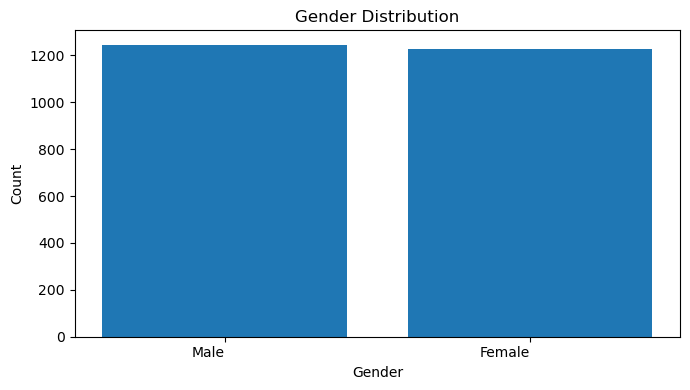

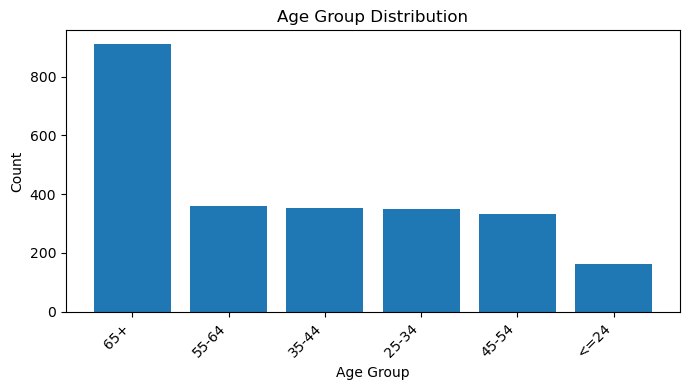

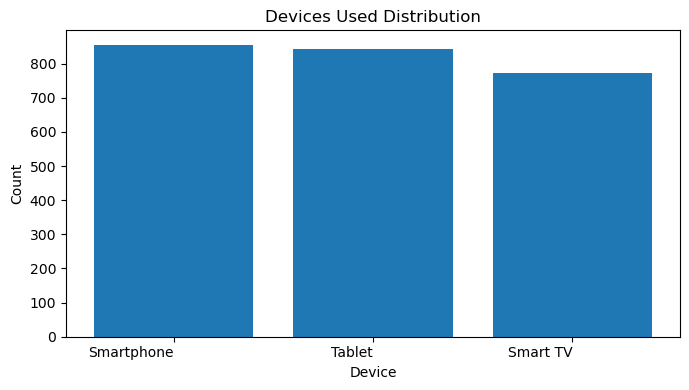

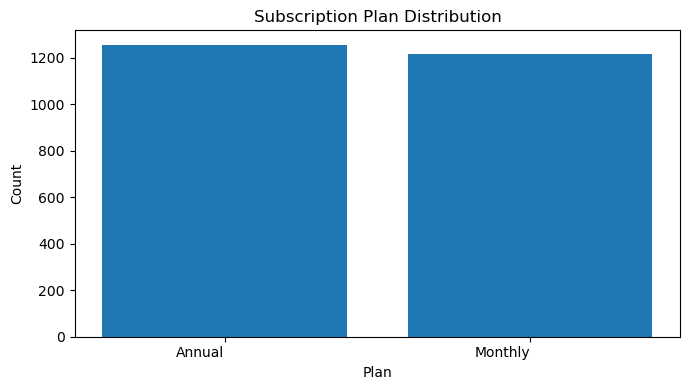

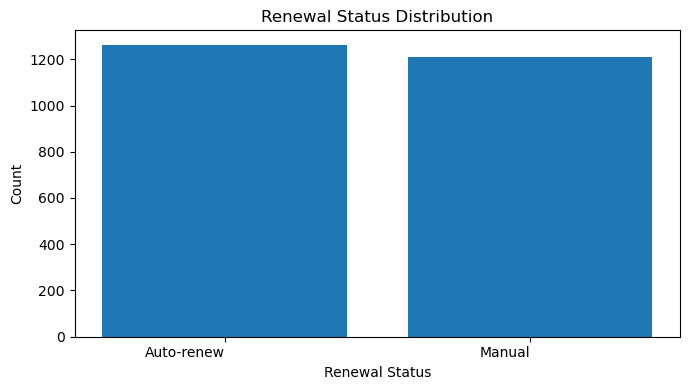

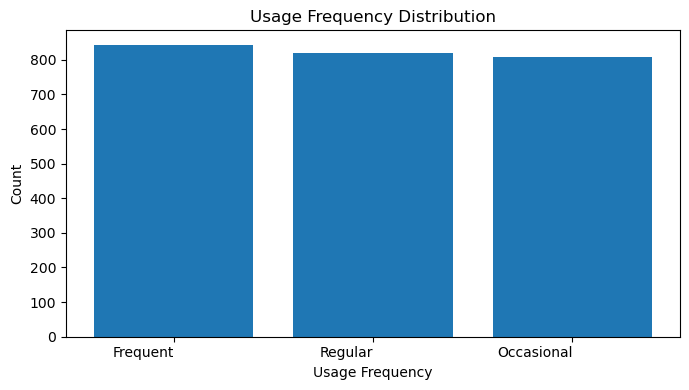

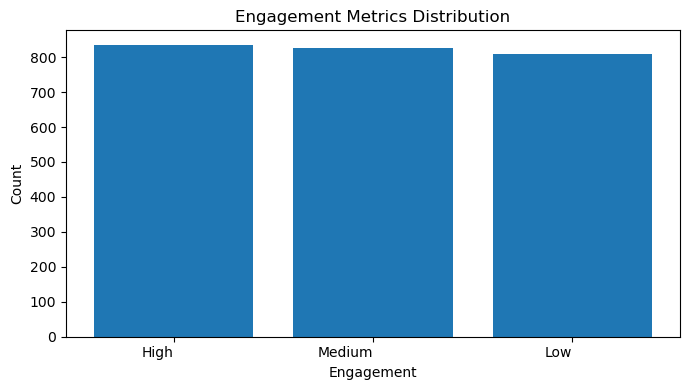

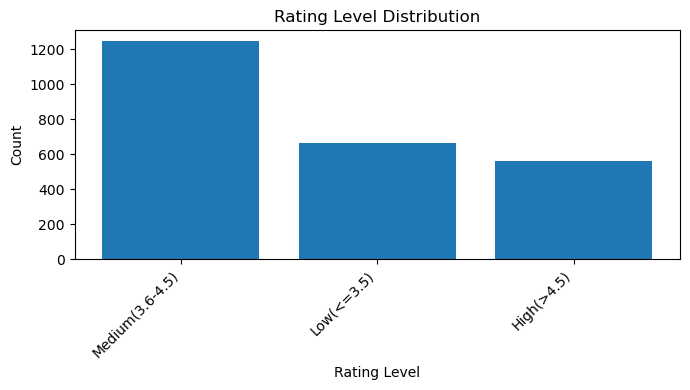

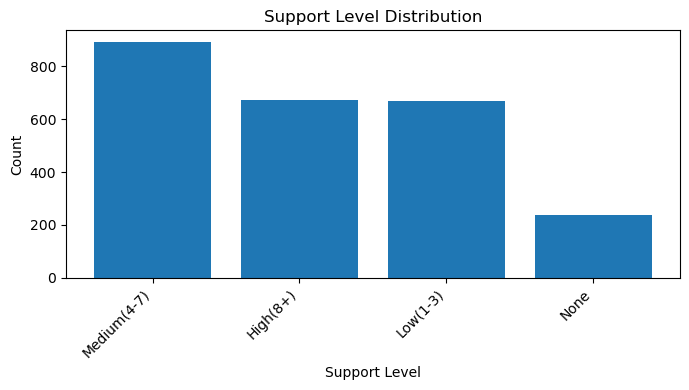

In [25]:
def plot_bar(series, title, xlabel, ylabel="Count", rotate=45):
    counts = series.value_counts()
    plt.figure(figsize=(7,4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotate, ha="right")
    plt.tight_layout()
    plt.show()

plot_bar(df_model["Gender"], "Gender Distribution", "Gender", rotate=0)
plot_bar(df_model["Age_Group"], "Age Group Distribution", "Age Group")
plot_bar(df_model["Devices Used"], "Devices Used Distribution", "Device", rotate=0)
plot_bar(df_model["Subscription Plan"], "Subscription Plan Distribution", "Plan", rotate=0)
plot_bar(df_model["Renewal Status"], "Renewal Status Distribution", "Renewal Status", rotate=0)
plot_bar(df_model["Usage Frequency"], "Usage Frequency Distribution", "Usage Frequency", rotate=0)
plot_bar(df_model["Engagement Metrics"], "Engagement Metrics Distribution", "Engagement", rotate=0)
plot_bar(df_model["Rating_Level"], "Rating Level Distribution", "Rating Level")
plot_bar(df_model["Support_Level"], "Support Level Distribution", "Support Level")

## 4.3 Bivariate Analysis

Before running Association Rule Mining (ARM), we first check whether pairs of variables show any visible relationship. This helps us understand the data better and confirms which attributes are meaningful candidates for rule mining.

For this purpose,
- We use cross-tabulation to count combinations of categories.
- We convert counts into row percentages to compare distributions fairly across groups of different sizes.
- We plot stacked bar charts (Row %) to make patterns easier to see.

In [26]:
def crosstab_percent(df, row_var, col_var):
    ct = pd.crosstab(df[row_var], df[col_var])
    pct = ct.div(ct.sum(axis=1), axis=0) * 100
    return ct, pct

def plot_stacked_pct(pct_df, title):
    ax = pct_df.plot(kind="bar", stacked=True, figsize=(10,5))
    plt.title(title)
    plt.ylabel("Percentage (%)")
    plt.xlabel(pct_df.index.name if pct_df.index.name else "")
    plt.legend(title=pct_df.columns.name if pct_df.columns.name else "", bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout()
    plt.show()

Gender,Female,Male
Favorite Genres,,
Action,197,180
Comedy,180,166
Documentary,161,173
Drama,185,175
Horror,176,199
Romance,173,190
Sci-Fi,154,162


Gender,Female,Male
Favorite Genres,,
Action,52.25,47.75
Comedy,52.02,47.98
Documentary,48.20,51.80
Drama,51.39,48.61
Horror,46.93,53.07
Romance,47.66,52.34
Sci-Fi,48.73,51.27


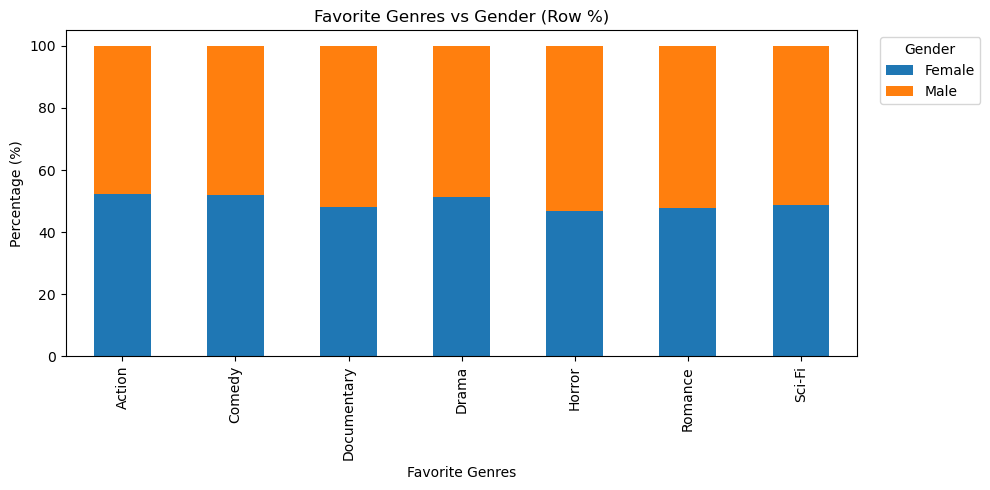

Engagement Metrics,High,Low,Medium
Renewal Status,,,
Auto-renew,445,398,419
Manual,390,411,408


Engagement Metrics,High,Low,Medium
Renewal Status,,,
Auto-renew,35.26,31.54,33.20
Manual,32.26,34.00,33.75


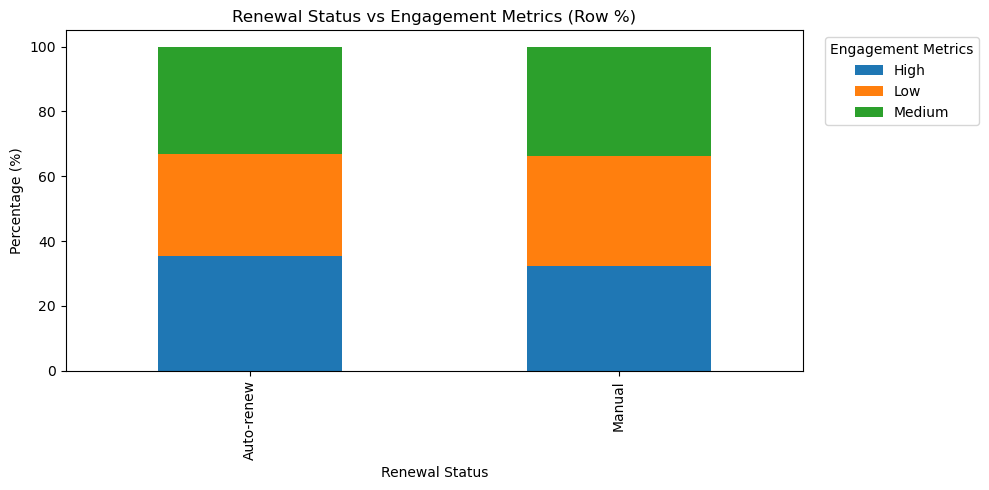

Support_Level,None,Low(1-3),Medium(4-7),High(8+)
Rating_Level,,,,
Low(<=3.5),77,187,219,183
Medium(3.6-4.5),109,332,466,339
High(>4.5),51,151,206,151


Support_Level,None,Low(1-3),Medium(4-7),High(8+)
Rating_Level,,,,
Low(<=3.5),11.56,28.08,32.88,27.48
Medium(3.6-4.5),8.75,26.65,37.40,27.21
High(>4.5),9.12,27.01,36.85,27.01


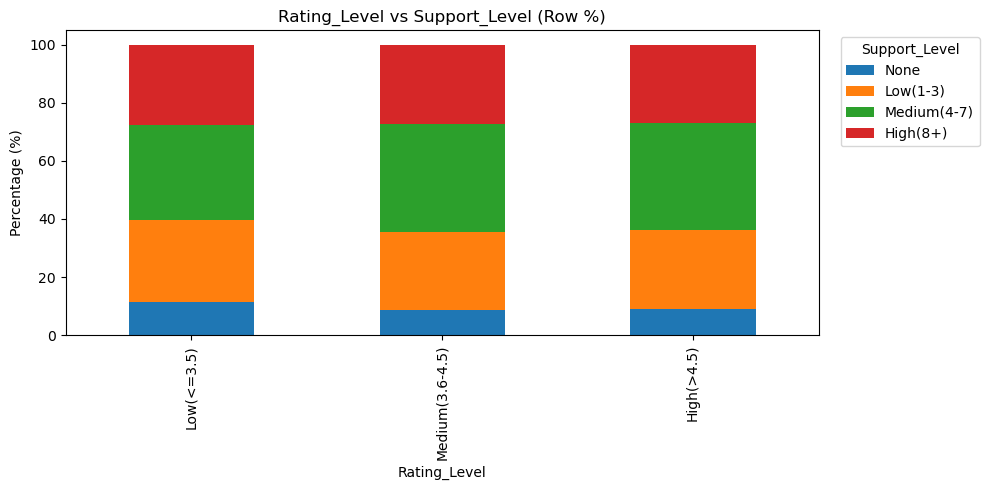

Age_Group,<=24,25-34,35-44,45-54,55-64,65+
Subscription Plan,,,,,,
Annual,96,197,168,173,177,444
Monthly,68,154,185,158,183,468


Age_Group,<=24,25-34,35-44,45-54,55-64,65+
Subscription Plan,,,,,,
Annual,7.65,15.70,13.39,13.78,14.10,35.38
Monthly,5.59,12.66,15.21,12.99,15.05,38.49


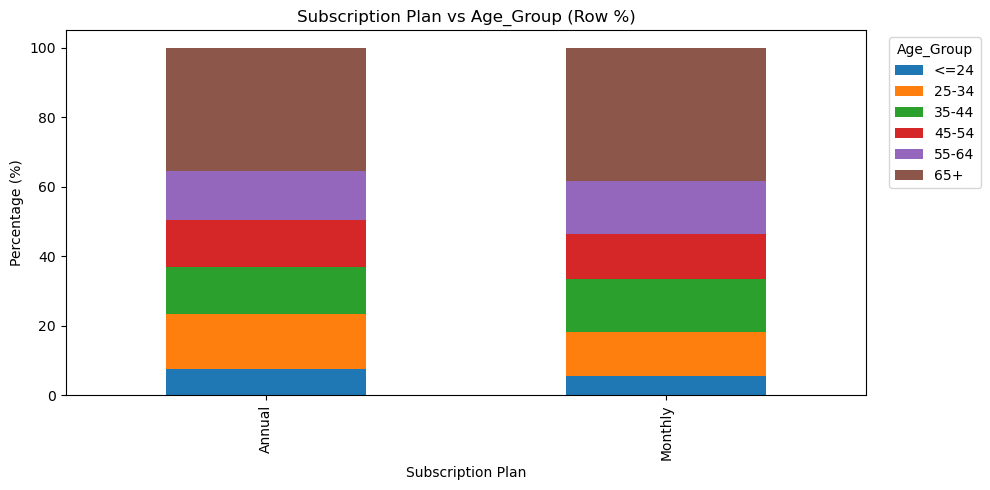

In [27]:
bivar_pairs = [
    ("Favorite Genres", "Gender"),
    ("Renewal Status", "Engagement Metrics"),
    ("Rating_Level", "Support_Level"),
    ("Subscription Plan", "Age_Group")
]

for row_var, col_var in bivar_pairs:
    ct, pct = crosstab_percent(df_model, row_var, col_var)
    display(ct)
    display(pct.round(2))
    plot_stacked_pct(pct, f"{row_var} vs {col_var} (Row %)")

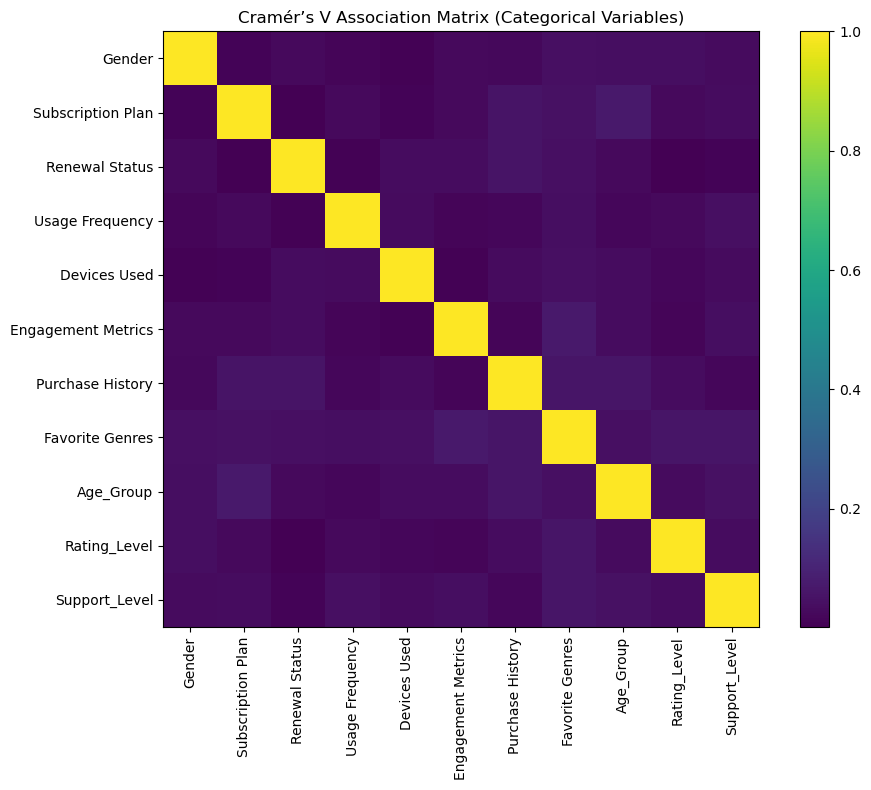

,Gender,Subscription Plan,Renewal Status,Usage Frequency,Devices Used,Engagement Metrics,Purchase History,Favorite Genres,Age_Group,Rating_Level,Support_Level
Gender,1.000,0.012,0.028,0.014,0.009,0.026,0.024,0.042,0.039,0.039,0.033
Subscription Plan,0.012,1.000,0.004,0.027,0.013,0.027,0.053,0.046,0.069,0.028,0.035
Renewal Status,0.028,0.004,1.000,0.009,0.035,0.034,0.056,0.045,0.028,0.002,0.011
Usage Frequency,0.014,0.027,0.009,1.000,0.030,0.016,0.019,0.041,0.019,0.029,0.043
Devices Used,0.009,0.013,0.035,0.030,1.000,0.009,0.030,0.045,0.036,0.021,0.031
Engagement Metrics,0.026,0.027,0.034,0.016,0.009,1.000,0.016,0.069,0.036,0.014,0.041
Purchase History,0.024,0.053,0.056,0.019,0.030,0.016,1.000,0.057,0.060,0.036,0.021
Favorite Genres,0.042,0.046,0.045,0.041,0.045,0.069,0.057,1.000,0.043,0.059,0.060
Age_Group,0.039,0.069,0.028,0.019,0.036,0.036,0.060,0.043,1.000,0.032,0.047
Rating_Level,0.039,0.028,0.002,0.029,0.021,0.014,0.036,0.059,0.032,1.000,0.037


In [28]:

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2, p, dof, expected = chi2_contingency(confusion_matrix)
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt((chi2 / n) / (min(r-1, k-1)))

cat_cols = [
    "Gender","Subscription Plan","Renewal Status","Usage Frequency",
    "Devices Used","Engagement Metrics","Purchase History","Favorite Genres",
    "Age_Group","Rating_Level","Support_Level"
]

cv_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for c1 in cat_cols:
    for c2 in cat_cols:
        cv_matrix.loc[c1, c2] = cramers_v(df_model[c1], df_model[c2]) if c1 != c2 else 1.0

plt.figure(figsize=(10,8))
plt.imshow(cv_matrix.values)
plt.xticks(range(len(cat_cols)), cat_cols, rotation=90)
plt.yticks(range(len(cat_cols)), cat_cols)
plt.title("Cramér’s V Association Matrix (Categorical Variables)")
plt.colorbar()
plt.tight_layout()
plt.show()

display(cv_matrix.round(3))


No strong or meaningful associations are present in this dataset based on the Cramér’s V table. 

## Key Observations from Bivariate Analysis

- **Favorite Genres vs Gender**  
  The distribution of favorite genres between male and female users is generally balanced. For most genres such as Action, Comedy, Drama, and Sci-Fi, both genders contribute almost equally. This indicates that genre preference does not show a strong dependency on gender within this dataset.

- **Renewal Status vs Engagement Metrics**  
  Users with high engagement levels appear slightly more concentrated in the auto-renew category compared to manual renewal. However, the differences across high, medium, and low engagement groups are not substantial. This suggests that engagement level alone may not be a strong factor influencing renewal behaviour.

- **Rating Level vs Support Level**  
  Most users across all rating levels fall under the medium and high support interaction categories. Interestingly, even users who provide high ratings tend to have a considerable number of support interactions. This implies that frequent customer support usage does not necessarily reflect negative user experience.

- **Subscription Plan vs Age Group**  
  Older users, particularly those aged 65 and above, make up the largest proportion of both annual and monthly subscriptions. Younger age groups contribute a smaller share overall. This suggests that age may influence subscription participation, with older users being more dominant on the platform.

- **Overall Association Strength (Cramér’s V Analysis)**  
  The Cramér’s V results show very low association values between most categorical variables. This indicates that there are no strong direct bivariate relationships present. Therefore, more meaningful insights are expected to emerge through multivariate analysis such as Association Rule Mining.


# 5. Association Rule Mining (ARM)

This chapter applies Association Rule Mining to discover frequent co-occurring patterns
among user profile, behaviour, preference, and subscription attributes.

First, we convert `df_model` into transaction-style one-hot encoding (attribute=value items)

Second, we generate frequent itemsets using the Apriori algorithm

Third, we generate association rules and evaluate them using support, confidence and lift.

Lastly, we filter rules for meaningful business interpretation.

## 5.1 Data Preparation for ARM

ARM requires each record to be represented as a set of "items".
We convert each categorical attribute into an item of the form:

`Column=Value`

Then, we one-hot encode these items into a transaction matrix where:
- rows = users
- columns = items
- values = True/False (item present or not)

This transaction matrix is used as input for Apriori.

In [29]:
# Create item-style values: "Column=Value" for all ARM columns
arm_items = df_model.copy()

for c in arm_items.columns:
    arm_items[c] = c + "=" + arm_items[c].astype(str)

arm_items.head()

,Gender,Subscription Plan,Renewal Status,Usage Frequency,Purchase History,Favorite Genres,Devices Used,Engagement Metrics,Age_Group,Rating_Level,Support_Level
0,Gender=Male,Subscription Plan=Annual,Renewal Status=Manual,Usage Frequency=Regular,Purchase History=Electronics,Favorite Genres=Documentary,Devices Used=Smart TV,Engagement Metrics=Medium,Age_Group=65+,Rating_Level=Medium(3.6-4.5),Support_Level=Low(1-3)
1,Gender=Male,Subscription Plan=Monthly,Renewal Status=Manual,Usage Frequency=Regular,Purchase History=Electronics,Favorite Genres=Horror,Devices Used=Smartphone,Engagement Metrics=Medium,Age_Group=45-54,Rating_Level=Medium(3.6-4.5),Support_Level=Medium(4-7)
2,Gender=Female,Subscription Plan=Monthly,Renewal Status=Manual,Usage Frequency=Regular,Purchase History=Books,Favorite Genres=Comedy,Devices Used=Smart TV,Engagement Metrics=Low,Age_Group=25-34,Rating_Level=Low(<=3.5),Support_Level=High(8+)
3,Gender=Female,Subscription Plan=Monthly,Renewal Status=Auto-renew,Usage Frequency=Regular,Purchase History=Electronics,Favorite Genres=Documentary,Devices Used=Smart TV,Engagement Metrics=High,Age_Group=55-64,Rating_Level=Low(<=3.5),Support_Level=Medium(4-7)
4,Gender=Male,Subscription Plan=Annual,Renewal Status=Auto-renew,Usage Frequency=Frequent,Purchase History=Clothing,Favorite Genres=Drama,Devices Used=Smart TV,Engagement Metrics=Low,Age_Group=55-64,Rating_Level=Medium(3.6-4.5),Support_Level=Low(1-3)


## 5.2 Data Mining (Frequent Itemsets and Rule Generation)

We apply Apriori to identify frequent itemsets using a minimum support threshold.
Then we generate association rules and evaluate them using confidence and lift.

Threshold choice rationale:
- **Support** ensures the pattern is not extremely rare.
- **Confidence** ensures the rule has reasonable reliability.
- **Lift > 1** indicates a positive association beyond chance.

In [30]:
# Use raw categorical values (no "Column=" inside the value)
transactions = pd.get_dummies(df_model.astype(str), prefix=df_model.columns, prefix_sep="=")

print("Transaction matrix shape:", transactions.shape)
transactions.head()

Transaction matrix shape: (2471, 38)


,Gender=Female,Gender=Male,Subscription Plan=Annual,Subscription Plan=Monthly,Renewal Status=Auto-renew,Renewal Status=Manual,Usage Frequency=Frequent,Usage Frequency=Occasional,Usage Frequency=Regular,Purchase History=Books,...,Age_Group=55-64,Age_Group=65+,Age_Group=<=24,Rating_Level=High(>4.5),Rating_Level=Low(<=3.5),Rating_Level=Medium(3.6-4.5),Support_Level=High(8+),Support_Level=Low(1-3),Support_Level=Medium(4-7),Support_Level=None
0,False,True,True,False,False,True,False,False,True,False,...,False,True,False,False,False,True,False,True,False,False
1,False,True,False,True,False,True,False,False,True,False,...,False,False,False,False,False,True,False,False,True,False
2,True,False,False,True,False,True,False,False,True,True,...,False,False,False,False,True,False,True,False,False,False
3,True,False,False,True,True,False,False,False,True,False,...,True,False,False,False,True,False,False,False,True,False
4,False,True,True,False,True,False,True,False,False,False,...,True,False,False,False,False,True,False,True,False,False


Given a dataset size of 2471 records, a minimum support threshold of 5% was selected to ensure statistical reliability and to avoid spurious co-occurrences.

In [31]:
min_support = 0.05

freq_items = apriori(transactions, min_support=min_support, use_colnames=True)
freq_items["length"] = freq_items["itemsets"].apply(lambda x: len(x))

print("Frequent itemsets found:", len(freq_items))
display(freq_items.sort_values(["support", "length"], ascending=False).head(10))

Frequent itemsets found: 1340


,support,itemsets,length
4,0.510724,(Renewal Status=Auto-renew),1
2,0.507892,(Subscription Plan=Annual),1
33,0.504249,(Rating_Level=Medium(3.6-4.5)),1
1,0.503845,(Gender=Male),1
0,0.496155,(Gender=Female),1
3,0.492108,(Subscription Plan=Monthly),1
5,0.489276,(Renewal Status=Manual),1
29,0.369081,(Age_Group=65+),1
36,0.360583,(Support_Level=Medium(4-7)),1
20,0.346014,(Devices Used=Smartphone),1


In [32]:
rules = association_rules(freq_items, metric="confidence", min_threshold=0.4)

# Add readable strings
rules["antecedents_str"] = rules["antecedents"].apply(itemset_to_str)
rules["consequents_str"] = rules["consequents"].apply(itemset_to_str)

print("Total rules generated:", len(rules))
rules.sort_values("lift", ascending=False).head()


Total rules generated: 1551


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedents_str,consequents_str
1550,"(Rating_Level=Medium(3.6-4.5), Gender=Male, Re...",(Purchase History=Books),0.119790,0.339943,0.050182,0.418919,1.232320,1.0,0.009460,1.135911,0.214179,0.122530,0.119650,0.283269,"Gender=Male, Rating_Level=Medium(3.6-4.5), Ren...",Purchase History=Books
1514,"(Rating_Level=Medium(3.6-4.5), Renewal Status=...",(Gender=Female),0.087414,0.496155,0.053015,0.606481,1.222362,1.0,0.009644,1.280358,0.199337,0.099924,0.218968,0.356667,"Purchase History=Electronics, Rating_Level=Med...",Gender=Female
1518,"(Rating_Level=Medium(3.6-4.5), Renewal Status=...",(Gender=Female),0.099150,0.496155,0.058276,0.587755,1.184619,1.0,0.009082,1.222197,0.173000,0.108515,0.181801,0.352605,"Rating_Level=Medium(3.6-4.5), Renewal Status=A...",Gender=Female
1165,"(Subscription Plan=Monthly, Engagement Metrics...",(Age_Group=65+),0.157831,0.369081,0.068798,0.435897,1.181034,1.0,0.010546,1.118447,0.182011,0.150177,0.105903,0.311150,"Engagement Metrics=Low, Subscription Plan=Monthly",Age_Group=65+
970,"(Support_Level=Low(1-3), Devices Used=Tablet)",(Subscription Plan=Annual),0.091866,0.507892,0.055038,0.599119,1.179620,1.0,0.008381,1.227567,0.167673,0.101040,0.185381,0.353743,"Devices Used=Tablet, Support_Level=Low(1-3)",Subscription Plan=Annual


# 6. Knowledge Evaluation
This chapter evaluates and interprets the discovered association rules to answer the four research questions.


## Utility Functions for Knowledge Evaluation

To keep evaluation consistent across RQs, we define helper functions to:
- filter rules by keywords in antecedent/consequent
- display top rules with support, confidence, lift
- create simple visualizations for rule strength

In [33]:
def show_rules_table(rules_df, top_n=10):
    cols = ["antecedents_str", "consequents_str", "support", "confidence", "lift"]
    return rules_df[cols].head(top_n)

def filter_rules_contains(rules_df, must_have=None, must_not_have=None, in_side="either"):
    """
    Filter rules where specified keywords exist
    """
    df = rules_df.copy()

    if must_have:
        for kw in must_have:
            if in_side == "antecedent":
                df = df[df["antecedents_str"].str.contains(kw, na=False)]
            elif in_side == "consequent":
                df = df[df["consequents_str"].str.contains(kw, na=False)]
            else:
                df = df[df["antecedents_str"].str.contains(kw, na=False) | df["consequents_str"].str.contains(kw, na=False)]

    if must_not_have:
        for kw in must_not_have:
            df = df[~df["antecedents_str"].str.contains(kw, na=False)]
            df = df[~df["consequents_str"].str.contains(kw, na=False)]

    return df

def rank_rules(rules_df):
    """Rank rules by lift first then confidence."""
    return rules_df.sort_values(["lift", "confidence", "support"], ascending=False)

def plot_top_lift(rules_df, title, top_n=10):
    """
    Cleaner lift bar chart:
    - x-axis uses Rule IDs (R1, R2, ...)
    - prints a readable mapping table under the chart
    """
    top = rules_df.head(top_n).copy().reset_index(drop=True)
    top["Rule_ID"] = ["R" + str(i+1) for i in range(len(top))]

    # Bar plot (clean x-axis)
    plt.figure(figsize=(9,4))
    plt.bar(top["Rule_ID"], top["lift"].values)
    plt.title(title)
    plt.ylabel("Lift")
    plt.xlabel("Rule ID")
    plt.tight_layout()
    plt.show()

    # Mapping table (readable)
    mapping = top[[
        "Rule_ID", "antecedents_str", "consequents_str",
        "support", "confidence", "lift"
    ]].copy()

    # Round for display
    mapping["support"] = mapping["support"].round(4)
    mapping["confidence"] = mapping["confidence"].round(4)
    mapping["lift"] = mapping["lift"].round(4)

    display(mapping)

def plot_support_confidence(rules_df, title):
    """Scatter plot of support vs confidence for a rule set."""
    plt.figure(figsize=(6,4))
    plt.scatter(rules_df["support"], rules_df["confidence"])
    plt.title(title)
    plt.xlabel("Support")
    plt.ylabel("Confidence")
    plt.tight_layout()
    plt.show()

## **RQ1.** Are users whose favourite genre is Horror more likely to be Male? <br>

In [34]:
rq1_rules = filter_rules_contains(
    rules, 
    must_have=["Favorite Genres=Horror", "Gender=Male"], 
    in_side="either")

# Rank and preview
rq1_rules = rank_rules(rq1_rules)
print("RQ1 rules found:", len(rq1_rules))
display(show_rules_table(rq1_rules))

RQ1 rules found: 1


,antecedents_str,consequents_str,support,confidence,lift
57,Favorite Genres=Horror,Gender=Male,0.080534,0.530667,1.053235


**Rule Identified:**
- Favorite Genres = Horror → Gender = Male
- Support ≈ 8.1%  
- Confidence ≈ 53%  
- Lift ≈ 1.05  

The rule indicates that a slight majority of users who prefer horror content are male. However, the lift value is only marginally greater than 1, suggesting that while a gender association exists, it is weak.

This pattern implies a mild demographic tendency rather than a strong segmentation factor. Horror content appeals to both genders, and gender alone is not a strong predictor of genre preference.

**Conclusion:**  
The result provides descriptive insight into audience composition but offers limited predictive or strategic value when used in isolation.


**RQ2:** Do users with high usage frequency or high engagement tend to show higher renewal rates or satisfaction ratings? <br>


In [35]:
rq2a_rules = filter_rules_contains(
    rules,
    must_have=[
        "Engagement Metrics=High",
        "Usage Frequency=Frequent",
        "Renewal Status"
    ],
    in_side="either"
)

rq2a_rules = rank_rules(rq2a_rules)
rq2a_rules["Outcome"] = "Renewal"

rq2b_rules = filter_rules_contains(
    rules,
    must_have=[
        "Engagement Metrics=High",
        "Usage Frequency=Frequent",
        "Rating_Level"
    ],
    in_side="either"
)

rq2b_rules = rank_rules(rq2b_rules)
rq2b_rules["Outcome"] = "Rating"

rq2_all_rules = pd.concat([rq2a_rules, rq2b_rules], ignore_index=True)

print("Total RQ2 rules found:", len(rq2_all_rules))
display(show_rules_table(rq2_all_rules))


Total RQ2 rules found: 2


,antecedents_str,consequents_str,support,confidence,lift
0,"Engagement Metrics=High, Usage Frequency=Frequent",Renewal Status=Auto-renew,0.065156,0.572954,1.121845
1,"Engagement Metrics=High, Usage Frequency=Frequent",Rating_Level=Medium(3.6-4.5),0.055443,0.487544,0.966872


**Rules Identified:**
- Engagement Metrics = High & Usage Frequency = Frequent → Renewal Status = Auto-renew  
  - Confidence ≈ 57%  
  - Lift ≈ 1.12  

- Engagement Metrics = High & Usage Frequency = Frequent → Rating Level = Medium (3.6-4.5)  
  - Confidence ≈ 49%  
  - Lift < 1  

Highly engaged and frequent users are more likely to demonstrate favorable renewal behavior, particularly auto-renewal, indicating a strong behavioral commitment to the platform. However, this same user group does not exhibit a corresponding increase in satisfaction ratings, as evidenced by the lack of positive lift for higher rating levels.

This divergence suggests that engagement-driven loyalty does not necessarily reflect higher perceived satisfaction. Users may remain active due to habit, necessity, or functional dependence rather than strong positive sentiment.

Engagement metrics are effective predictors of renewal behavior but are insufficient on their own for assessing user satisfaction. Behavioral and perceptual metrics should therefore be evaluated separately.

**RQ3.** How does user satisfaction vary with the frequency of customer support interactions?

In [36]:
# Defining support levels
support_levels = ["High", "Medium", "Low", "None"]

for level in support_levels:
    antecedent_filtered = filter_rules_contains(
        rules,
        must_have=[f"Support_Level={level}"],
        in_side="antecedent"
    )

    final_filtered = filter_rules_contains(
        antecedent_filtered,
        must_have=["Rating_Level"],
        in_side="consequent"
    )
    
    print(f"\n=== Rules for Support_Level={level} ===")
    print("Number of rules found:", len(final_filtered))
    display(show_rules_table(final_filtered, top_n=10))




=== Rules for Support_Level=High ===
Number of rules found: 8


,antecedents_str,consequents_str,support,confidence,lift
236,Support_Level=High(8+),Rating_Level=Medium(3.6-4.5),0.137191,0.503715,0.998940
508,"Gender=Female, Support_Level=High(8+)",Rating_Level=Medium(3.6-4.5),0.067179,0.518750,1.028757
795,"Gender=Male, Support_Level=High(8+)",Rating_Level=Medium(3.6-4.5),0.070012,0.490085,0.971910
991,"Subscription Plan=Annual, Support_Level=High(8+)",Rating_Level=Medium(3.6-4.5),0.070822,0.507246,1.005944
1180,"Subscription Plan=Monthly, Support_Level=High(8+)",Rating_Level=Medium(3.6-4.5),0.066370,0.500000,0.991573
1295,"Renewal Status=Auto-renew, Support_Level=High(8+)",Rating_Level=Medium(3.6-4.5),0.068798,0.497076,0.985774
1403,"Renewal Status=Manual, Support_Level=High(8+)",Rating_Level=Medium(3.6-4.5),0.068393,0.510574,1.012543
1475,"Devices Used=Tablet, Support_Level=High(8+)",Rating_Level=Medium(3.6-4.5),0.050182,0.523207,1.037595



=== Rules for Support_Level=Medium ===
Number of rules found: 21


,antecedents_str,consequents_str,support,confidence,lift
238,Support_Level=Medium(4-7),Rating_Level=Medium(3.6-4.5),0.188588,0.523008,1.037201
512,"Gender=Female, Support_Level=Medium(4-7)",Rating_Level=Medium(3.6-4.5),0.098745,0.536264,1.063489
799,"Gender=Male, Support_Level=Medium(4-7)",Rating_Level=Medium(3.6-4.5),0.089842,0.509174,1.009767
995,"Subscription Plan=Annual, Support_Level=Medium...",Rating_Level=Medium(3.6-4.5),0.096317,0.548387,1.087532
1184,"Subscription Plan=Monthly, Support_Level=Mediu...",Rating_Level=Medium(3.6-4.5),0.092270,0.498906,0.989403
1299,"Renewal Status=Auto-renew, Support_Level=Mediu...",Rating_Level=Medium(3.6-4.5),0.099150,0.540839,1.072562
1407,"Renewal Status=Manual, Support_Level=Medium(4-7)",Rating_Level=Medium(3.6-4.5),0.089437,0.504566,1.000628
1418,"Support_Level=Medium(4-7), Usage Frequency=Fre...",Rating_Level=Medium(3.6-4.5),0.066370,0.535948,1.062863
1429,"Support_Level=Medium(4-7), Usage Frequency=Occ...",Rating_Level=Medium(3.6-4.5),0.064346,0.533557,1.058122
1438,"Support_Level=Medium(4-7), Usage Frequency=Reg...",Rating_Level=Medium(3.6-4.5),0.057871,0.498258,0.988118



=== Rules for Support_Level=Low ===
Number of rules found: 8


,antecedents_str,consequents_str,support,confidence,lift
237,Support_Level=Low(1-3),Rating_Level=Medium(3.6-4.5),0.134359,0.495522,0.982693
510,"Gender=Female, Support_Level=Low(1-3)",Rating_Level=Medium(3.6-4.5),0.072036,0.525074,1.041298
797,"Gender=Male, Support_Level=Low(1-3)",Rating_Level=Medium(3.6-4.5),0.062323,0.465257,0.922672
993,"Subscription Plan=Annual, Support_Level=Low(1-3)",Rating_Level=Medium(3.6-4.5),0.070822,0.491573,0.974861
1182,"Subscription Plan=Monthly, Support_Level=Low(1-3)",Rating_Level=Medium(3.6-4.5),0.063537,0.500000,0.991573
1297,"Renewal Status=Auto-renew, Support_Level=Low(1-3)",Rating_Level=Medium(3.6-4.5),0.067584,0.479885,0.951682
1405,"Renewal Status=Manual, Support_Level=Low(1-3)",Rating_Level=Medium(3.6-4.5),0.066775,0.512422,1.016208
1485,"Age_Group=65+, Support_Level=Low(1-3)",Rating_Level=Medium(3.6-4.5),0.053824,0.523622,1.038419



=== Rules for Support_Level=None ===
Number of rules found: 0


,antecedents_str,consequents_str,support,confidence,lift


We observe that across high, medium, and low support interaction levels, the most frequent outcome is:
- Rating Level = Medium (3.6–4.5)

Confidence values remain consistently around 50 - 55%, with lift values close to 1 across all support levels.

Support interaction frequency does not significantly influence satisfaction ratings.

**Conclusion:**  
User ratings appear compressed within the medium range, suggesting that support volume alone does not strongly affect perceived satisfaction.


**RQ4.** What type of audience tends to have low engagement metrics or monthly subscription plans? 

In [37]:
# Filtering antecedents = "Engagement Metrics=Low"
rq4_rules_step1 = filter_rules_contains(
    rules,
    must_have=["Engagement Metrics=Low"],
    in_side="antecedent"
)

# Further filtering antecedents = "Subscription Plan=Monthly"
rq4_rules = filter_rules_contains(
    rq4_rules_step1,
    must_have=["Subscription Plan=Monthly"],
    in_side="antecedent"
)

# Ranking and displaying
rq4_rules = rank_rules(rq4_rules)
print("RQ4 rules found:", len(rq4_rules))
display(show_rules_table(rq4_rules, top_n=10))


RQ4 rules found: 6


,antecedents_str,consequents_str,support,confidence,lift
1165,"Engagement Metrics=Low, Subscription Plan=Monthly",Age_Group=65+,0.068798,0.435897,1.181034
1055,"Engagement Metrics=Low, Subscription Plan=Monthly",Renewal Status=Manual,0.078915,0.500000,1.021919
584,"Engagement Metrics=Low, Subscription Plan=Monthly",Gender=Male,0.079725,0.505128,1.002548
308,"Engagement Metrics=Low, Subscription Plan=Monthly",Gender=Female,0.078106,0.494872,0.997413
1016,"Engagement Metrics=Low, Subscription Plan=Monthly",Renewal Status=Auto-renew,0.078915,0.500000,0.979002
1168,"Engagement Metrics=Low, Subscription Plan=Monthly",Rating_Level=Medium(3.6-4.5),0.077701,0.492308,0.976318


**Antecedent:**
- Engagement Metrics = Low & Subscription Plan = Monthly

**Key Consequents Identified:**  
- Age Group = 65+  
  - Lift ≈ 1.18  
- Gender = Male  
  - Lift ≈ 1.00  
- Gender = Female  
  - Lift ≈ 1.00  
- Renewal Status (Manual / Auto-renew)  
  - Lift ≈ 1.00  
- Rating Level = Medium (3.6-4.5)  
  - Lift < 1  

The association with users aged 65+ exhibits a notably higher lift than other consequents, indicating a meaningful overrepresentation of older users within the low-engagement, monthly subscription segment. In contrast, gender and renewal outcomes show lift values close to 1, suggesting no meaningful deviation from the overall population distribution.

The elevated lift for the 65+ age group suggests that low engagement in this segment is more strongly linked to age-related factors rather than dissatisfaction or gender-based preferences.

**Conclusion:**  
Age is a significant distinguishing factor for low-engagement monthly subscribers, while gender, renewal behavior, and satisfaction levels provide limited explanatory value.


## Overall Summary of Findings and Insights

The Association Rule Mining (ARM) analysis highlights several behavioural patterns within the dataset. However, most of the discovered relationships are moderate in strength, suggesting that user behaviour is influenced by multiple interacting factors rather than a single dominant variable.

### Key Findings by Research Question

- **RQ1: Genre Preference and Gender**
  - Users whose favourite genre is Horror show a slightly higher likelihood of being male.
  - The rule demonstrates moderate confidence (≈53%) but a lift only marginally above 1.
  - This indicates a weak gender-based tendency rather than a strong or actionable segmentation.
  - Genre preferences appear broadly balanced across genders.

- **RQ2: Engagement, Usage, and Renewal or Satisfaction**
  - Users with high engagement metrics and frequent usage are more likely to enable auto-renewal.
  - This relationship shows moderate confidence (≈57%) and a lift above 1, indicating a meaningful behavioural association.
  - The same group is not strongly associated with high satisfaction ratings.
  - Instead, medium rating levels are more common, suggesting continued usage may be driven by habit or convenience rather than strong positive sentiment.

- **RQ3: Customer Support Interactions and Satisfaction**
  - Across high, medium, and low support interaction levels, the most frequent outcome is a medium satisfaction rating (3.6–4.5).
  - Confidence values remain around 50–55%, with lift values close to 1.
  - This suggests that the frequency of support interactions does not significantly influence user satisfaction.
  - High support usage does not necessarily indicate dissatisfaction.

- **RQ4: Low Engagement and Monthly Subscription Patterns**
  - Low engagement users on monthly subscription plans are more strongly associated with the 65+ age group.
  - This relationship shows a noticeably higher lift compared to other consequents.
  - Gender, renewal status, and satisfaction ratings show lift values close to 1, indicating weak associations.
  - Age emerges as the most distinguishing factor within this segment.

### Overall Insights

- Engagement metrics are the most informative predictors of renewal behaviour.
- Age plays a significant role in explaining low engagement among monthly subscribers.
- Satisfaction ratings are concentrated within the medium range across most user groups, limiting their discriminative power.
- Most associations identified show moderate confidence and low lift, indicating weak standalone relationships.

### Final Remark

While these ARM findings provide useful descriptive insights into user behaviour, they are **not sufficient to be relied upon for critical business decision-making**. The absence of high-confidence and high-lift rules indicates limited predictive strength. As such, these results should be interpreted as exploratory patterns rather than definitive evidence, and they should be complemented with additional analytical techniques or datasets before informing strategic decisions.